In [28]:
# Customer Segmentation Using Clustering
# Based on Mall Customers dataset

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [30]:
print("1. Project Overview")
print("-" * 50)
print("This project demonstrates a data mining system that segments customers based on")
print("their spending behavior and income levels using clustering algorithms.")
print("The analysis helps businesses develop targeted marketing strategies and improve customer relationship management.")
print("-" * 50)

1. Project Overview
--------------------------------------------------
This project demonstrates a data mining system that segments customers based on
their spending behavior and income levels using clustering algorithms.
The analysis helps businesses develop targeted marketing strategies and improve customer relationship management.
--------------------------------------------------


In [31]:
# 1. Data Acquisition and Preparation
print("\n2. Dataset Acquisition and Preparation")
print("-" * 50)

# Load the Mall Customers dataset
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nColumn names in the dataset:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
print(df.info())

print("\nStatistical summary of numerical features:")
print(df.describe())

print("\nChecking for missing values:")
print(df.isnull().sum())


2. Dataset Acquisition and Preparation
--------------------------------------------------
Dataset Shape: (200, 5)

First 5 rows of the dataset:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Column names in the dataset:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                 

In [21]:
print("1. Project Overview")
print("-" * 50)
print("This project demonstrates a data mining system that segments customers based on")
print("their spending behavior and income levels using clustering algorithms.")
print("The analysis helps businesses develop targeted marketing strategies and improve customer relationship management.")
print("-" * 50)

1. Project Overview
--------------------------------------------------
This project demonstrates a data mining system that segments customers based on
their spending behavior and income levels using clustering algorithms.
The analysis helps businesses develop targeted marketing strategies and improve customer relationship management.
--------------------------------------------------



3. Exploratory Data Analysis
--------------------------------------------------

Gender Distribution:
Genre
Female    112
Male       88
Name: count, dtype: int64


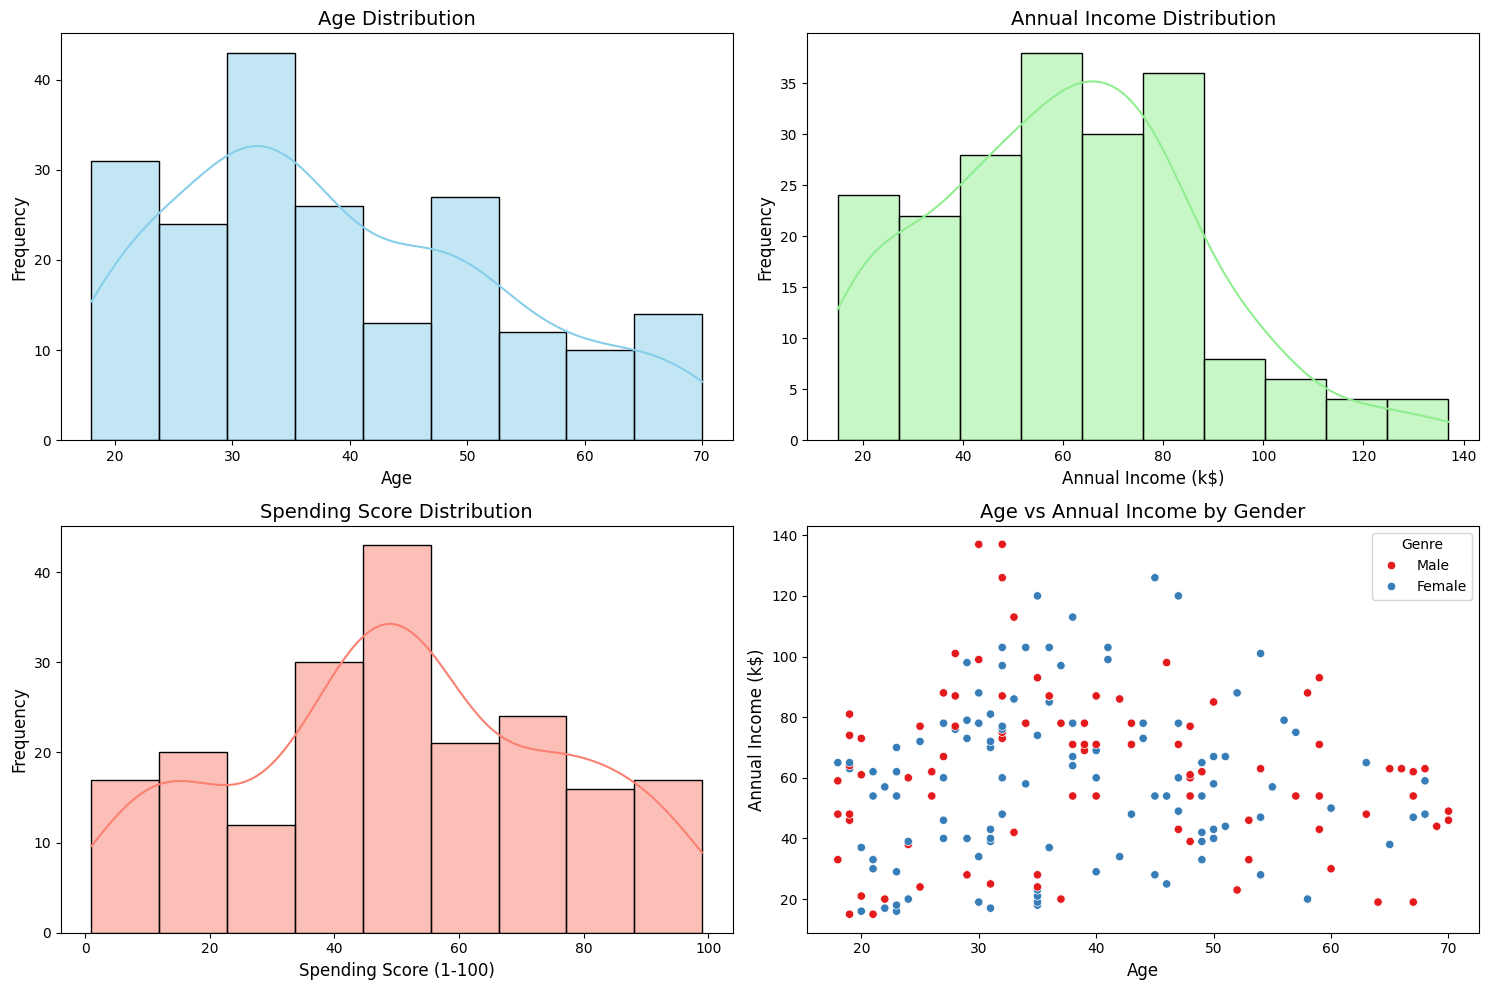

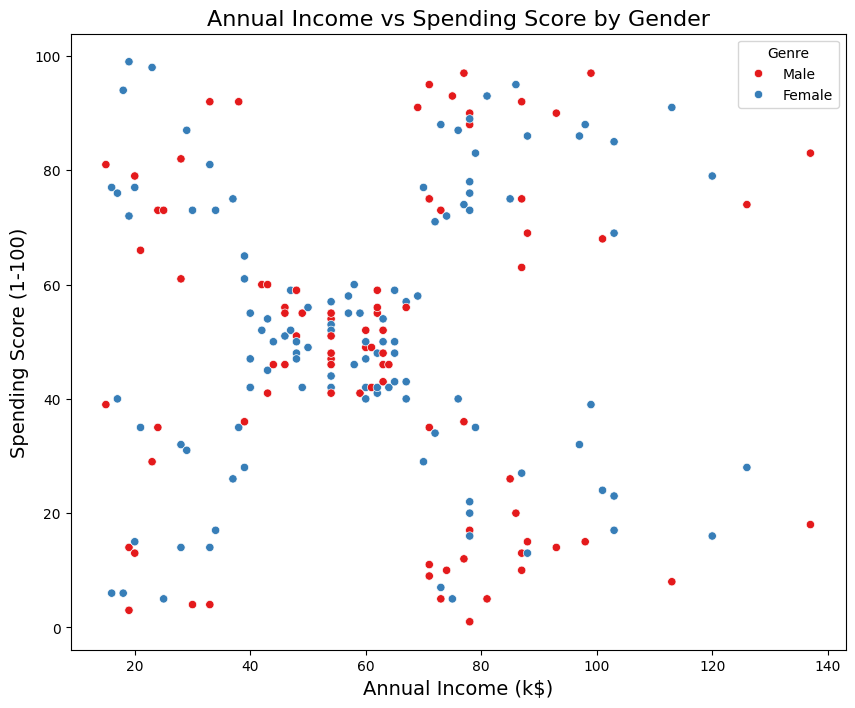

In [34]:
# 3. Exploratory Data Analysis
print("\n3. Exploratory Data Analysis")
print("-" * 50)

# Gender distribution - using the correct column name (case sensitive)
print("\nGender Distribution:")
gender_counts = df['Genre'].value_counts()  # Note: using 'Gender' with uppercase G
print(gender_counts)

# Set up visualization style
plt.figure(figsize=(15, 10))

# Age Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Annual Income Distribution
plt.subplot(2, 2, 2)
sns.histplot(df['Annual Income (k$)'], kde=True, color='lightgreen')
plt.title('Annual Income Distribution', fontsize=14)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Spending Score Distribution
plt.subplot(2, 2, 3)
sns.histplot(df['Spending Score (1-100)'], kde=True, color='salmon')
plt.title('Spending Score Distribution', fontsize=14)
plt.xlabel('Spending Score (1-100)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Age vs Annual Income
plt.subplot(2, 2, 4)
sns.scatterplot(x='Age', y='Annual Income (k$)', hue='Genre', data=df, palette='Set1')
plt.title('Age vs Annual Income by Gender', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Annual Income (k$)', fontsize=12)

plt.tight_layout()
plt.savefig('eda_plots.png')

# Create a joint plot for Annual Income vs Spending Score
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Genre', data=df, palette='Set1')
plt.title('Annual Income vs Spending Score by Gender', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=14)
plt.ylabel('Spending Score (1-100)', fontsize=14)
plt.savefig('income_vs_spending.png')

In [35]:
# 4. Feature Selection and Preprocessing
print("\n4. Feature Selection and Preprocessing")
print("-" * 50)

# Select features for clustering
print("Selected features for clustering: 'Annual Income (k$)' and 'Spending Score (1-100)'")
X = df.iloc[:, [3, 4]].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features standardized to ensure equal contribution to clustering")


4. Feature Selection and Preprocessing
--------------------------------------------------
Selected features for clustering: 'Annual Income (k$)' and 'Spending Score (1-100)'
Features standardized to ensure equal contribution to clustering



5. Finding the Optimal Number of Clusters (Elbow Method)
--------------------------------------------------
For n_clusters = 2, the silhouette score is 0.321
For n_clusters = 3, the silhouette score is 0.467
For n_clusters = 4, the silhouette score is 0.494
For n_clusters = 5, the silhouette score is 0.555
For n_clusters = 6, the silhouette score is 0.540
For n_clusters = 7, the silhouette score is 0.528
For n_clusters = 8, the silhouette score is 0.455
For n_clusters = 9, the silhouette score is 0.457
For n_clusters = 10, the silhouette score is 0.443

Based on the Elbow Method and Silhouette Scores, the optimal number of clusters is 5.


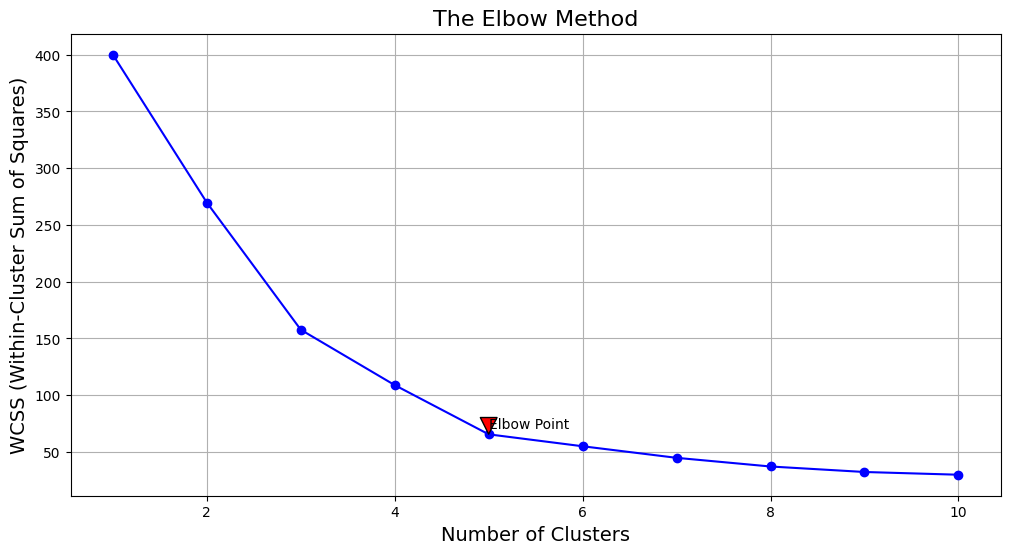

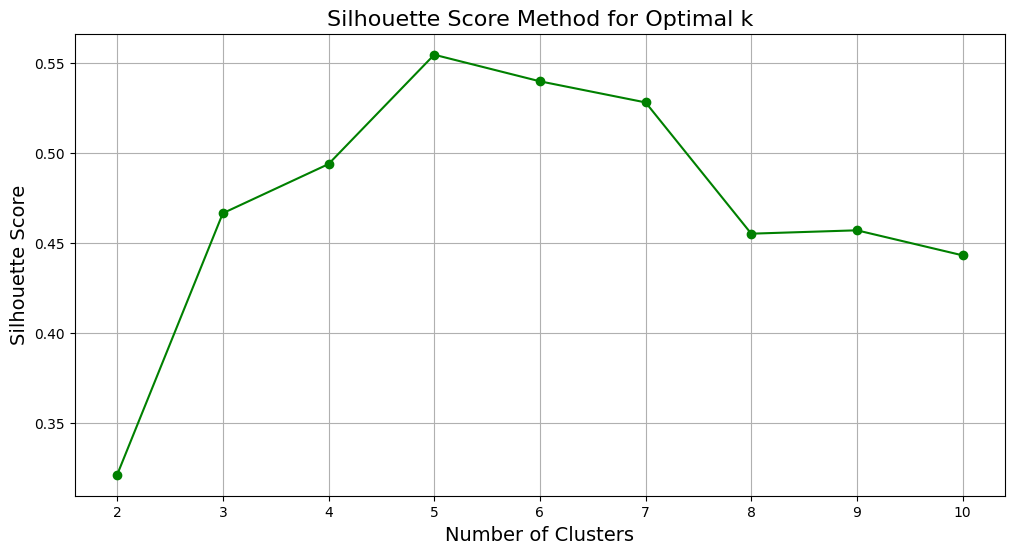

In [36]:
# 5. Finding the Optimal Number of Clusters (Elbow Method)
print("\n5. Finding the Optimal Number of Clusters (Elbow Method)")
print("-" * 50)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='blue')
plt.title('The Elbow Method', fontsize=16)
plt.xlabel('Number of Clusters', fontsize=14)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=14)
plt.grid(True)
plt.annotate('Elbow Point', xy=(5, wcss[4]), xytext=(5, wcss[4]+5),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.savefig('elbow_method.png')

# Calculate silhouette scores for different cluster numbers
silhouette_scores = []
for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {n_clusters}, the silhouette score is {silhouette_avg:.3f}")

# Plot silhouette scores
plt.figure(figsize=(12, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='-', color='green')
plt.title('Silhouette Score Method for Optimal k', fontsize=16)
plt.xlabel('Number of Clusters', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.grid(True)
plt.savefig('silhouette_scores.png')

print("\nBased on the Elbow Method and Silhouette Scores, the optimal number of clusters is 5.")



6. K-Means Clustering Implementation
--------------------------------------------------


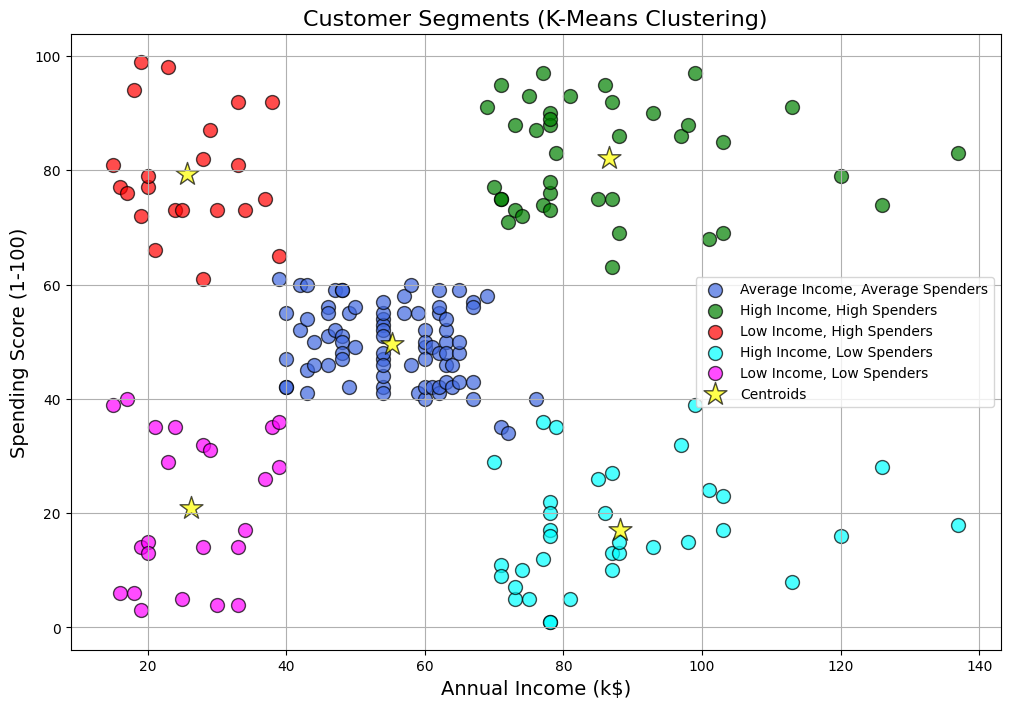

In [37]:
# 6. K-Means Clustering Implementation
print("\n6. K-Means Clustering Implementation")
print("-" * 50)

# Apply K-Means with the optimal number of clusters (k=5)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['Cluster'] = y_kmeans

# Plot the K-Means clusters
plt.figure(figsize=(12, 8))
colors = ['royalblue', 'green', 'red', 'cyan', 'magenta']
labels = ['Average Income, Average Spenders', 'High Income, High Spenders',
          'Low Income, High Spenders', 'High Income, Low Spenders', 'Low Income, Low Spenders']

# Get the original values (unstandardized) for plotting
for i, color, label in zip(range(optimal_k), colors, labels):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=100, c=color, label=label, alpha=0.7, edgecolor='black')

# Plot the centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='yellow', label='Centroids', alpha=0.7, edgecolor='black', marker='*')

plt.title('Customer Segments (K-Means Clustering)', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=14)
plt.ylabel('Spending Score (1-100)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.savefig('kmeans_clusters.png')


7. Implementing Additional Clustering Methods
--------------------------------------------------

7.1 Hierarchical Clustering

7.2 DBSCAN Clustering


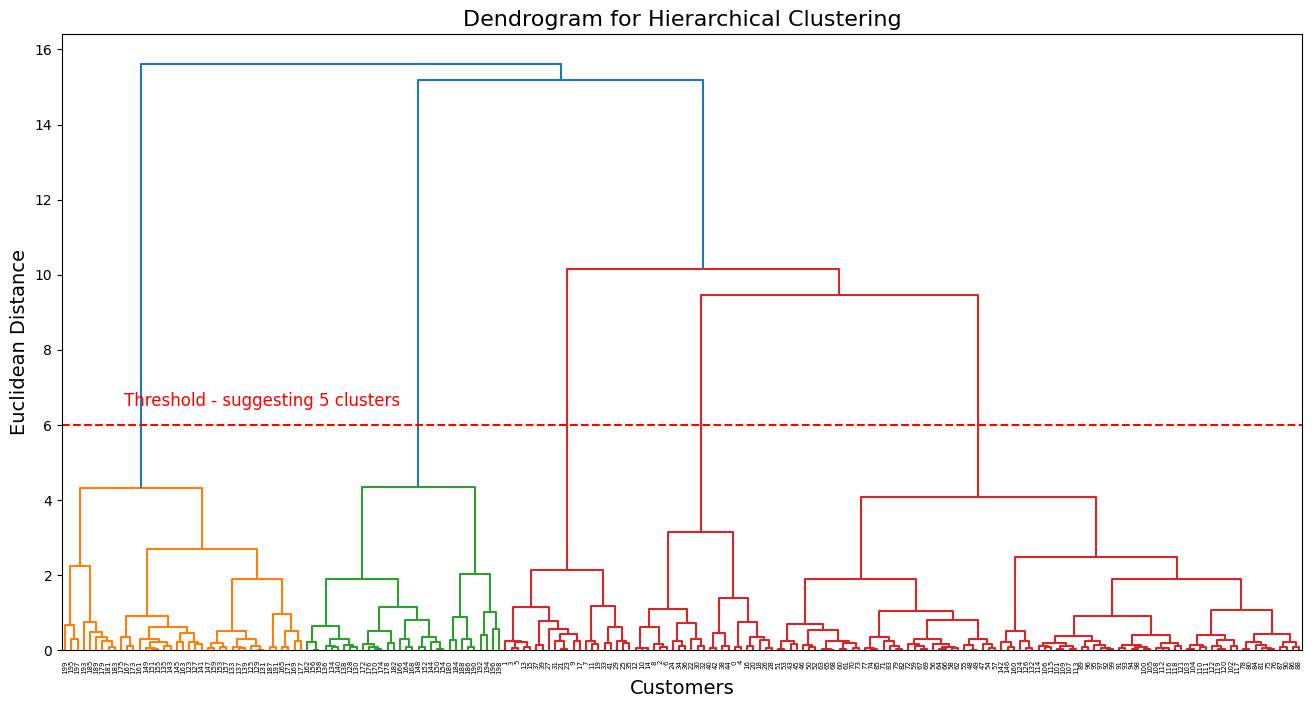

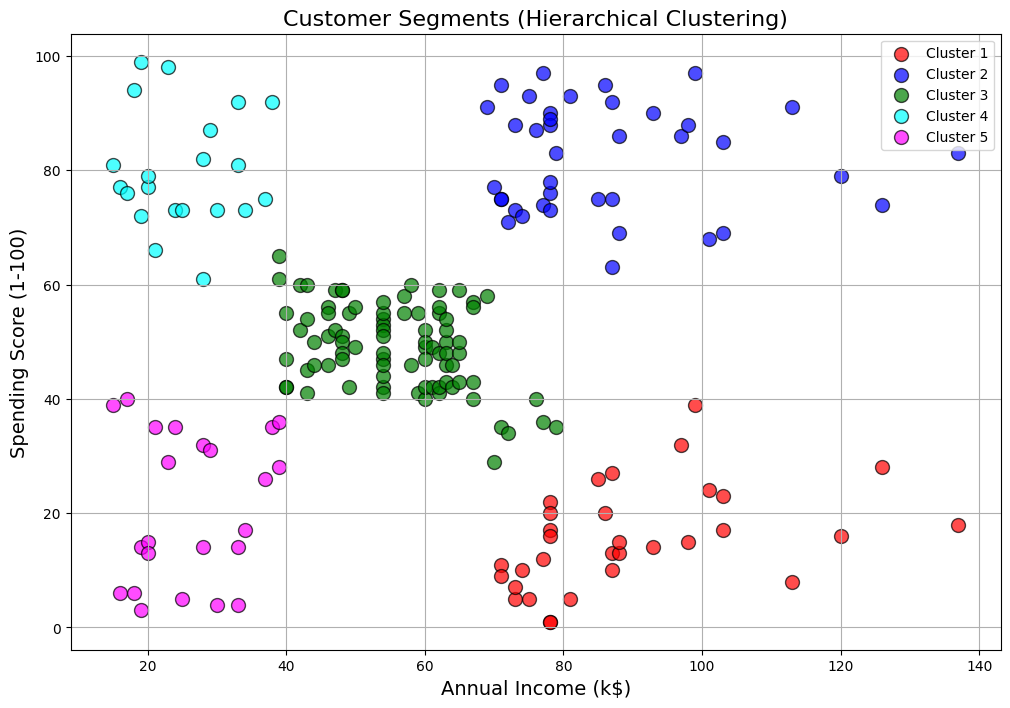

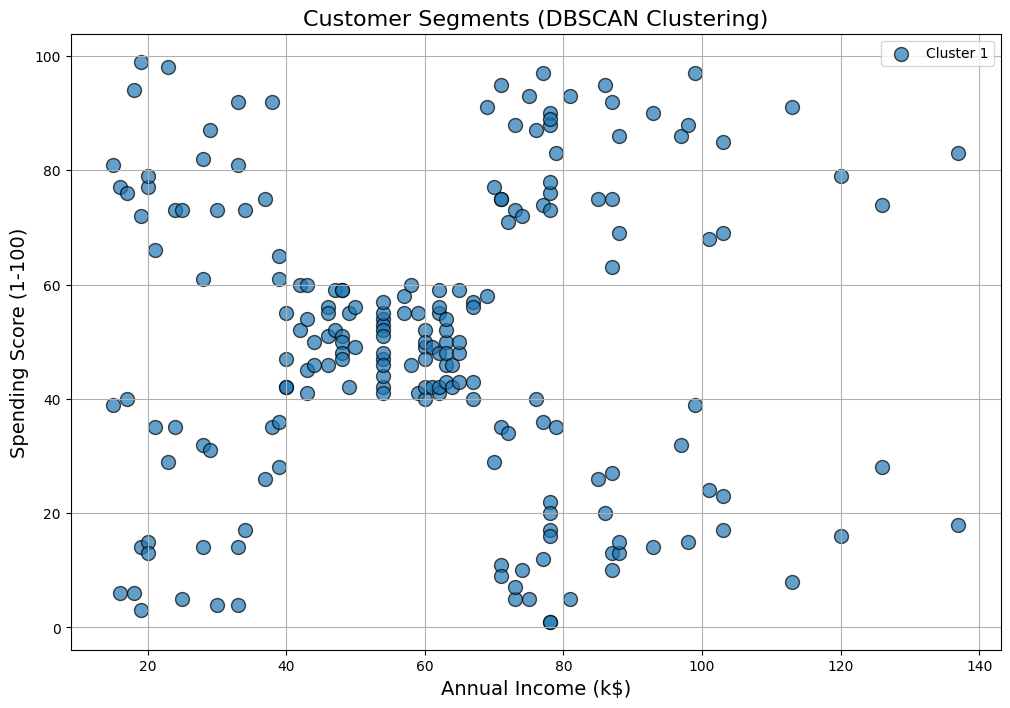

In [52]:
# 7. Implementing Additional Clustering Methods
print("\n7. Implementing Additional Clustering Methods")
print("-" * 50)

# 7.1 Hierarchical Clustering
print("\n7.1 Hierarchical Clustering")

# Plot dendrogram to find optimal clusters
plt.figure(figsize=(16, 8))
dendrogram_plot = dendrogram(linkage(X_scaled, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering', fontsize=16)
plt.xlabel('Customers', fontsize=14)
plt.ylabel('Euclidean Distance', fontsize=14)
plt.axhline(y=6, color='r', linestyle='--')
plt.text(100, 6.5, 'Threshold - suggesting 5 clusters', color='red', fontsize=12)
plt.savefig('dendrogram.png')

hierarchical = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
y_hc = hierarchical.fit_predict(X_scaled)

# Plot the Hierarchical Clustering results
plt.figure(figsize=(12, 8))
for i, color, label in zip(range(optimal_k), colors, labels):
    plt.scatter(X[y_hc == i, 0], X[y_hc == i, 1],
                s=100, c=color, label=f'Cluster {i+1}', alpha=0.7, edgecolor='black')

plt.title('Customer Segments (Hierarchical Clustering)', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=14)
plt.ylabel('Spending Score (1-100)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.savefig('hierarchical_clusters.png')

# 7.2 DBSCAN Clustering
print("\n7.2 DBSCAN Clustering")

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

# Plot the DBSCAN Clustering results
plt.figure(figsize=(12, 8))
unique_labels = np.unique(y_dbscan)
for label in unique_labels:
    if label == -1:
        # Noise points in black
        plt.scatter(X[y_dbscan == label, 0], X[y_dbscan == label, 1],
                    s=100, c='black', label='Noise', alpha=0.5)
    else:
        plt.scatter(X[y_dbscan == label, 0], X[y_dbscan == label, 1],
                    s=100, label=f'Cluster {label+1}', alpha=0.7, edgecolor='black')

plt.title('Customer Segments (DBSCAN Clustering)', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=14)
plt.ylabel('Spending Score (1-100)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.savefig('dbscan_clusters.png')



8. Three-Dimensional Clustering Analysis
--------------------------------------------------


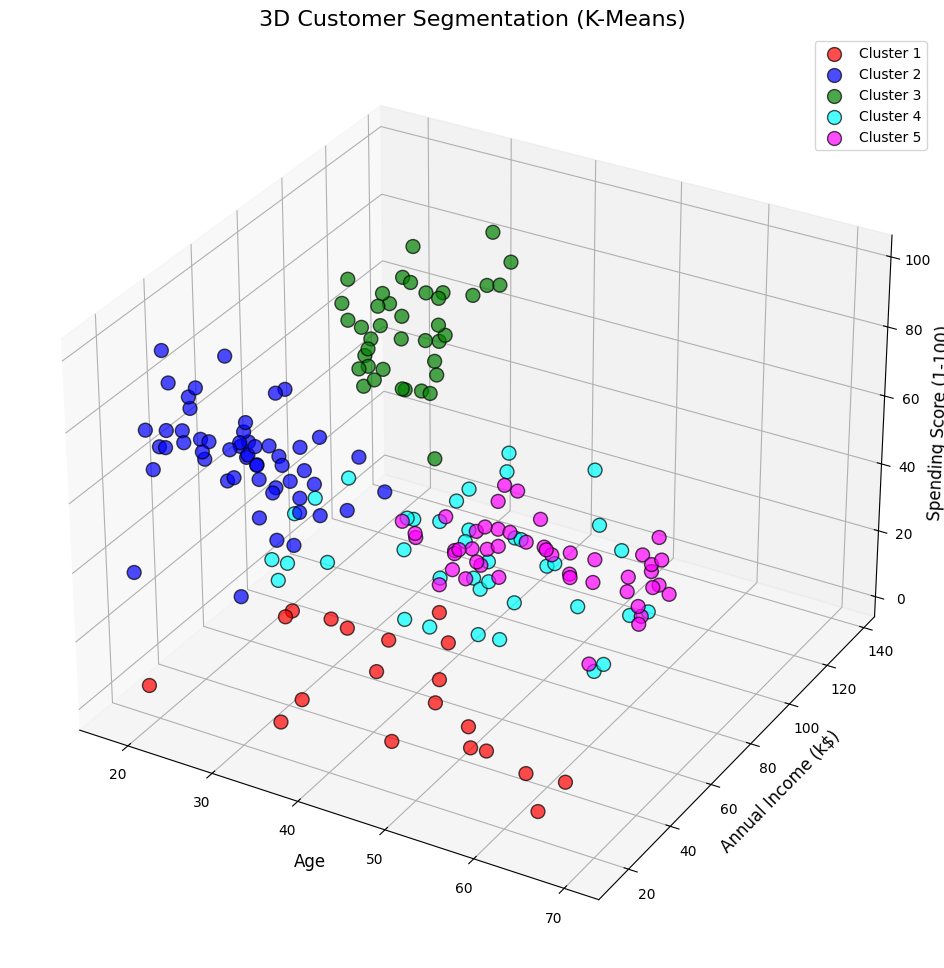

In [55]:
# 8. Three-Dimensional Clustering (using all three numeric features)
print("\n8. Three-Dimensional Clustering Analysis")
print("-" * 50)

# Select all three numeric features for 3D clustering
X_3d = df.iloc[:, 2:5].values  # Age, Annual Income, Spending Score

# Standardize the features
X_3d_scaled = scaler.fit_transform(X_3d)

# Apply K-Means with the optimal number of clusters (k=5)
kmeans_3d = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans_3d = kmeans_3d.fit_predict(X_3d_scaled)

# Plot the 3D clusters
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

for i, color in zip(range(optimal_k), colors):
    ax.scatter(X_3d[y_kmeans_3d == i, 0], X_3d[y_kmeans_3d == i, 1], X_3d[y_kmeans_3d == i, 2],
               s=100, c=color, label=f'Cluster {i+1}', alpha=0.7, edgecolor='black')

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Annual Income (k$)', fontsize=12)
ax.set_zlabel('Spending Score (1-100)', fontsize=12)
ax.set_title('3D Customer Segmentation (K-Means)', fontsize=16)
plt.legend(fontsize=10)
plt.savefig('3d_kmeans_clusters.png')


9. Cluster Analysis and Business Insights
--------------------------------------------------

Cluster Statistics:
           Age         Annual Income (k$)          Spending Score (1-100)      \
          mean min max               mean min  max                   mean min   
Cluster                                                                         
0        42.72  18  70              55.30  39   76                  49.52  34   
1        32.69  27  40              86.54  69  137                  82.13  63   
2        25.27  18  35              25.73  15   39                  79.36  61   
3        41.11  19  59              88.20  70  137                  17.11   1   
4        45.22  19  67              26.30  15   39                  20.91   3   

            CustomerID  
        max      count  
Cluster                 
0        61         81  
1        97         39  
2        99         22  
3        39         35  
4        40         23  


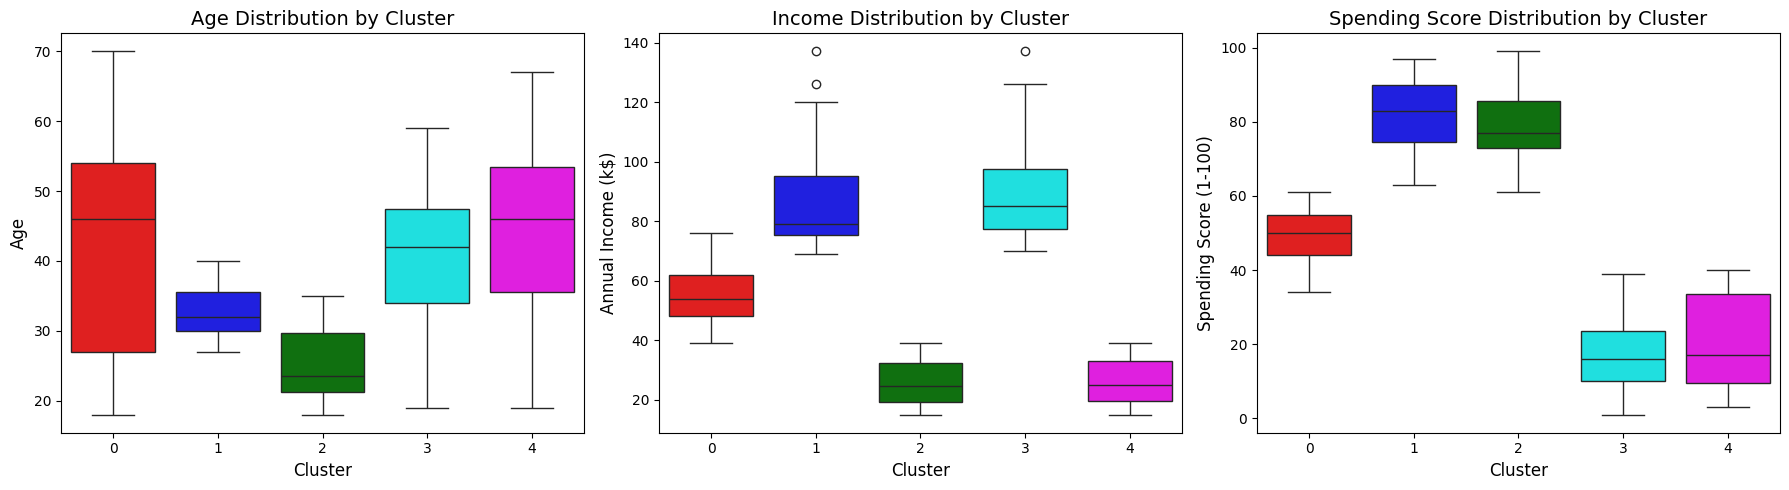

<Figure size 1000x600 with 0 Axes>

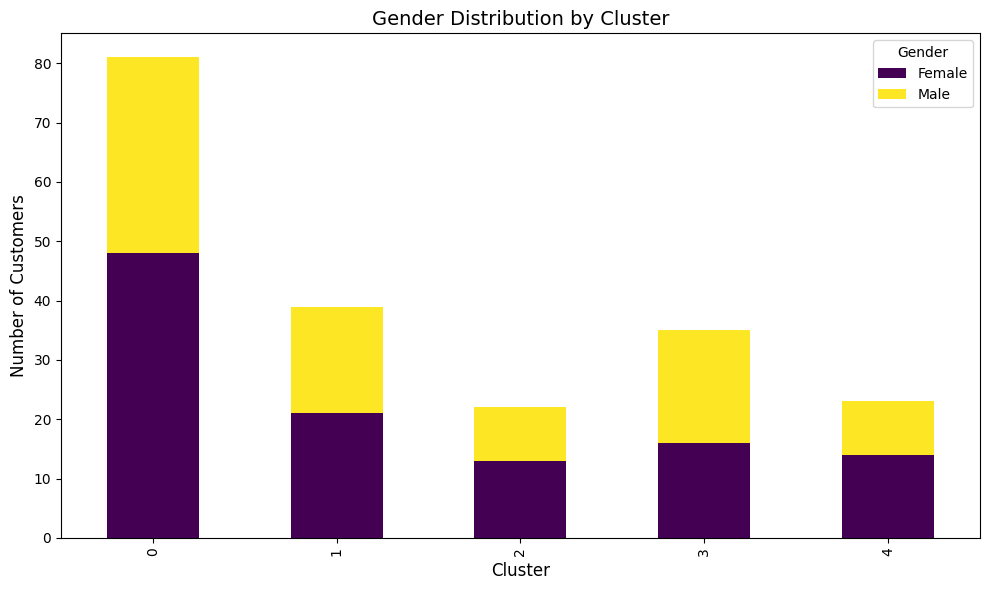

In [57]:
# 9. Cluster Analysis and Business Insights
print("\n9. Cluster Analysis and Business Insights")
print("-" * 50)

# Analyze the clusters
cluster_analysis = df.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'Annual Income (k$)': ['mean', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'min', 'max'],
    'CustomerID': 'count'
}).round(2)

print("\nCluster Statistics:")
print(cluster_analysis)

# Visualize the cluster statistics
plt.figure(figsize=(18, 5))

# Age distribution by cluster
plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster', y='Age', data=df, palette=colors[:df['Cluster'].nunique()])
plt.title('Age Distribution by Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Age', fontsize=12)

# Income distribution by cluster
plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster', y='Annual Income (k$)', data=df, palette=colors[:df['Cluster'].nunique()])
plt.title('Income Distribution by Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Annual Income (k$)', fontsize=12)

# Spending Score distribution by cluster
plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster', y='Spending Score (1-100)', data=df, palette=colors[:df['Cluster'].nunique()])
plt.title('Spending Score Distribution by Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)

plt.tight_layout()
plt.savefig('cluster_distributions.png')
plt.show()

# Gender distribution in each cluster
plt.figure(figsize=(10, 6))
gender_cluster = pd.crosstab(df['Cluster'], df['Gender'])  # Make sure 'Gender' is correctly capitalized in your DataFrame!
gender_cluster.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10,6))

plt.title('Gender Distribution by Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('gender_distribution.png')
plt.show()


In [59]:
print("\n10. Business Insights and Marketing Recommendations")
print("-" * 50)

cluster_names = {
    0: "Average Income, Average Spenders",
    1: "High Income, High Spenders",
    2: "Low Income, High Spenders",
    3: "High Income, Low Spenders",
    4: "Low Income, Low Spenders"
}

business_recommendations = {
    0: """
Cluster 0 - Average Income, Average Spenders (Potential Cluster Size: {})

Profile:
- Average Age: {:.1f} years
- Annual Income: ${:.1f}k
- Spending Score: {:.1f}/100

Marketing Recommendations:
✔️ Create balanced pricing strategies with mid-range options
✔️ Implement moderate promotional offers to increase spending
✔️ Focus on value-for-money messaging and quality assurance
✔️ Develop loyalty programs to encourage repeat purchases
""",
    1: """
Cluster 1 - High Income, High Spenders (Potential Cluster Size: {})

Profile:
- Average Age: {:.1f} years
- Annual Income: ${:.1f}k
- Spending Score: {:.1f}/100

Marketing Recommendations:
💎 Implement premium loyalty programs and exclusive experiences
💎 Introduce high-end product lines with premium pricing
💎 Focus on customer retention through personalized services
💎 Utilize prestige marketing and exclusivity messaging
""",
    2: """
Cluster 2 - Low Income, High Spenders (Potential Cluster Size: {})

Profile:
- Average Age: {:.1f} years
- Annual Income: ${:.1f}k
- Spending Score: {:.1f}/100

Marketing Recommendations:
💡 Develop value-based loyalty programs emphasizing affordability
💡 Create aspirational but accessible product offerings
💡 Use promotional offers highlighting value and quality
💡 Implement installment payment options and special financing
""",
    3: """
Cluster 3 - High Income, Low Spenders (Potential Cluster Size: {})

Profile:
- Average Age: {:.1f} years
- Annual Income: ${:.1f}k
- Spending Score: {:.1f}/100

Marketing Recommendations:
📢 Implement educational marketing about product benefits and quality
📢 Develop trust-building campaigns highlighting value propositions
📢 Consider exclusive price matching or best-price guarantees
📢 Focus on quality, durability, and long-term value messaging
""",
    4: """
Cluster 4 - Low Income, Low Spenders (Potential Cluster Size: {})

Profile:
- Average Age: {:.1f} years
- Annual Income: ${:.1f}k
- Spending Score: {:.1f}/100

Marketing Recommendations:
🛒 Create tiered pricing strategies emphasizing affordable options
🛒 Implement aggressive sales promotions and discount programs
🛒 Focus on essential product lines with strong value propositions
🛒 Consider limited-time offers to drive immediate conversions
"""
}

# Generate and print business recommendations for each cluster
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    cluster_size = len(cluster_data)
    avg_age = cluster_data['Age'].mean().round(1)
    avg_income = cluster_data['Annual Income (k$)'].mean().round(1)
    avg_spending = cluster_data['Spending Score (1-100)'].mean().round(1)

    print(f"\n========== {cluster_names[i]} ==========")
    print(business_recommendations[i].format(cluster_size, avg_age, avg_income, avg_spending))



10. Business Insights and Marketing Recommendations
--------------------------------------------------

========== Average Income, Average Spenders ==========

Cluster 0 - Average Income, Average Spenders (Potential Cluster Size: 81)

Profile:
- Average Age: 42.7 years
- Annual Income: $55.3k
- Spending Score: 49.5/100

Marketing Recommendations:
✔️ Create balanced pricing strategies with mid-range options  
✔️ Implement moderate promotional offers to increase spending  
✔️ Focus on value-for-money messaging and quality assurance  
✔️ Develop loyalty programs to encourage repeat purchases


========== High Income, High Spenders ==========

Cluster 1 - High Income, High Spenders (Potential Cluster Size: 39)

Profile:
- Average Age: 32.7 years
- Annual Income: $86.5k
- Spending Score: 82.1/100

Marketing Recommendations:
💎 Implement premium loyalty programs and exclusive experiences  
💎 Introduce high-end product lines with premium pricing  
💎 Focus on customer retention through persona

In [60]:
# 11. Save the Results
print("\n11. Saving the Results")
print("-" * 50)

# Add cluster names to the dataframe
df['Cluster_Name'] = df['Cluster'].map(cluster_names)

# Save the segmented customer data to CSV
df.to_csv('customer_segments.csv', index=False)
print("Customer segmentation results saved to 'customer_segments.csv'")

# Save cluster statistics to CSV
cluster_stats = pd.DataFrame({
    'Cluster': range(optimal_k),
    'Cluster_Name': [cluster_names[i] for i in range(optimal_k)],
    'Size': [len(df[df['Cluster'] == i]) for i in range(optimal_k)],
    'Size_Percentage': [100 * len(df[df['Cluster'] == i]) / len(df) for i in range(optimal_k)],
    'Avg_Age': [df[df['Cluster'] == i]['Age'].mean() for i in range(optimal_k)],
    'Avg_Income': [df[df['Cluster'] == i]['Annual Income (k$)'].mean() for i in range(optimal_k)],
    'Avg_Spending': [df[df['Cluster'] == i]['Spending Score (1-100)'].mean() for i in range(optimal_k)],
    'Female_Percentage': [100 * len(df[(df['Cluster'] == i) & (df['Gender'] == 'Female')]) / len(df[df['Cluster'] == i]) for i in range(optimal_k)],
    'Male_Percentage': [100 * len(df[(df['Cluster'] == i) & (df['Gender'] == 'Male')]) / len(df[df['Cluster'] == i]) for i in range(optimal_k)]
})

cluster_stats.to_csv('cluster_statistics.csv', index=False)
print("Cluster statistics saved to 'cluster_statistics.csv'")

print("\n12. Conclusion")
print("-" * 50)
print("The Customer Segmentation project successfully identified five distinct customer segments based on")
print("spending behavior and income levels. The implementation demonstrates the complete data mining workflow")
print("from data acquisition through exploratory analysis to clustering implementation and business insight generation.")
print("\nThe identified customer segments provide a foundation for targeted marketing strategies and improved")
print("customer relationship management across various business domains including retail, e-commerce,")
print("financial services, and hospitality.")
print("-" * 50)


11. Saving the Results
--------------------------------------------------
Customer segmentation results saved to 'customer_segments.csv'
Cluster statistics saved to 'cluster_statistics.csv'

12. Conclusion
--------------------------------------------------
The Customer Segmentation project successfully identified five distinct customer segments based on
spending behavior and income levels. The implementation demonstrates the complete data mining workflow
from data acquisition through exploratory analysis to clustering implementation and business insight generation.

The identified customer segments provide a foundation for targeted marketing strategies and improved
customer relationship management across various business domains including retail, e-commerce,
financial services, and hospitality.
--------------------------------------------------
